In [2]:
# Import all necessary files and create variables
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
import pandas as pd
import os
from ipywidgets import interact, Dropdown
import seaborn as sns
import numpy as np

In [3]:
# Load the data
file_path = 'C:/Users/glori/OneDrive/Desktop/UnRar/final_bushfire_data/cleaned-bushfire-data.csv'  # Ensure this path is correct
bushfire_df = pd.read_csv(file_path)

# Preview the data
print(bushfire_df.head())
print(bushfire_df.info())

   object_id                               general_cause controlled_date  \
0          1  Power generation/transmission/distribution        2/2/2005   
1          2                                     Natural       5/12/2004   
2          3                     Debris and open burning       5/31/2004   
3          4                                     Natural        7/3/2004   
4          5                                     Natural        7/3/2004   

  controlled_time  fire_size fire_class   latitude   longitude state  \
0          1730.0       0.10          A  40.036944 -121.005833    CA   
1          1530.0       0.25          A  38.933056 -120.404444    CA   
2          2024.0       0.10          A  38.984167 -120.735556    CA   
3          1400.0       0.10          A  38.559167 -119.913333    CA   
4          1200.0       0.10          A  38.559167 -119.933056    CA   

  discovery_day discovery_datetime      origin  
0     Wednesday   2005-02-02 13:00  Accidental  
1     Wednes

In [4]:
# Convert dates to datetime format
bushfire_df['controlled_date'] = pd.to_datetime(bushfire_df['controlled_date'], errors='coerce')
bushfire_df['discovery_datetime'] = pd.to_datetime(bushfire_df['discovery_datetime'], errors='coerce')

# Check for missing values
print(bushfire_df.isnull().sum())


object_id                  0
general_cause              0
controlled_date       894813
controlled_time            0
fire_size                  0
fire_class                 0
latitude                   0
longitude                  0
state                      0
discovery_day              0
discovery_datetime         0
origin                     0
dtype: int64


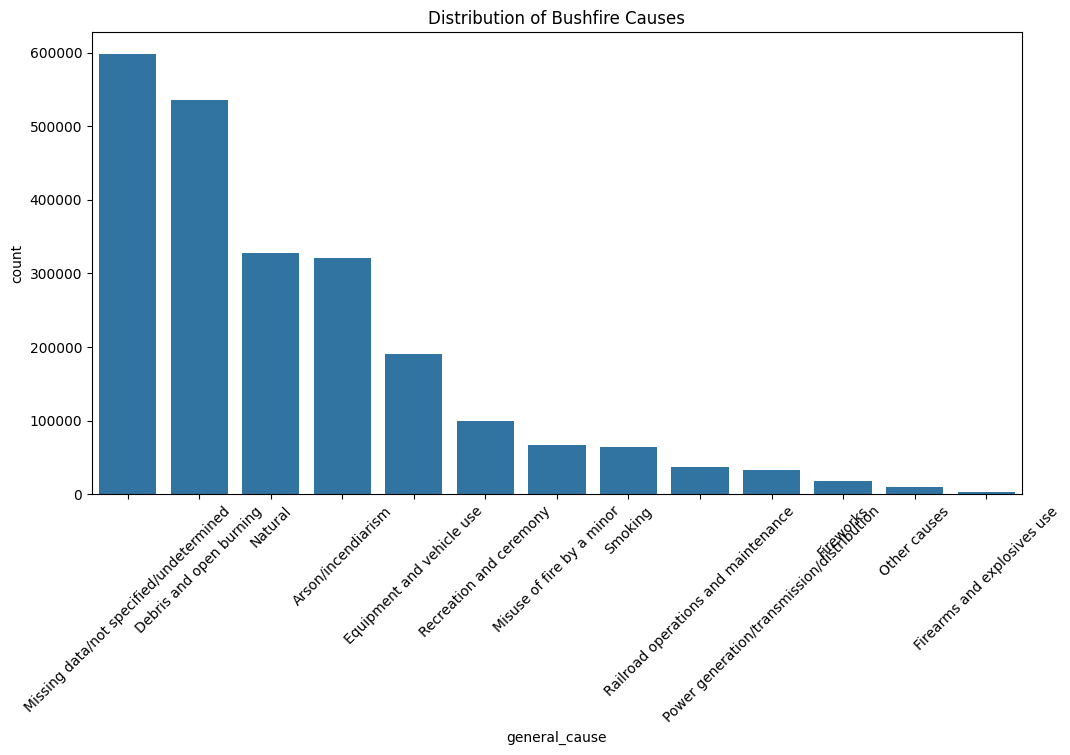

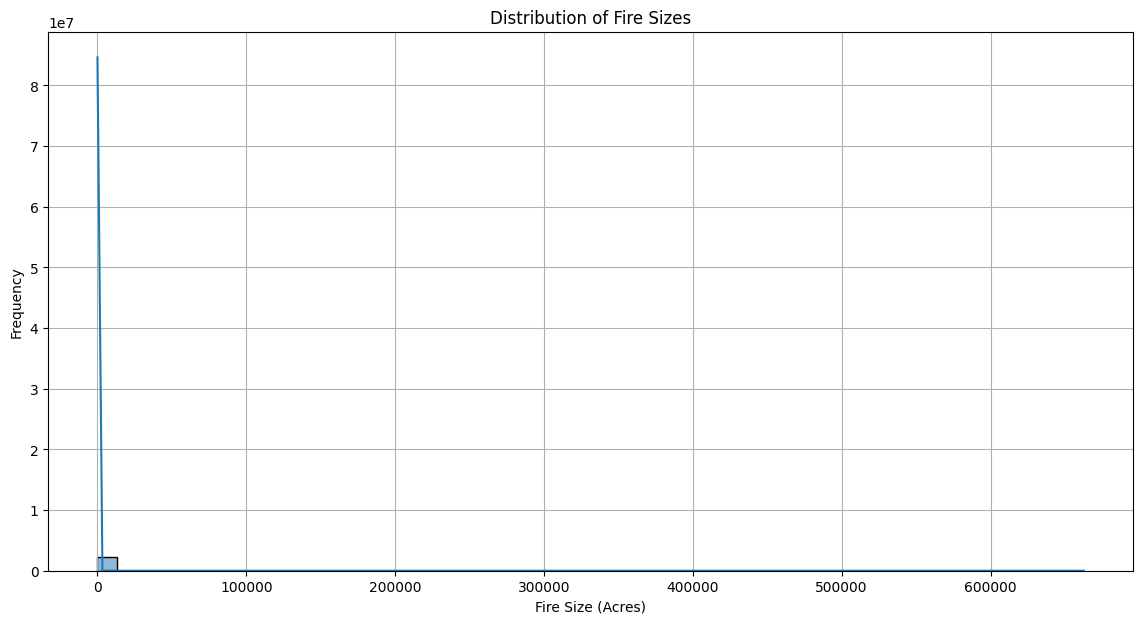

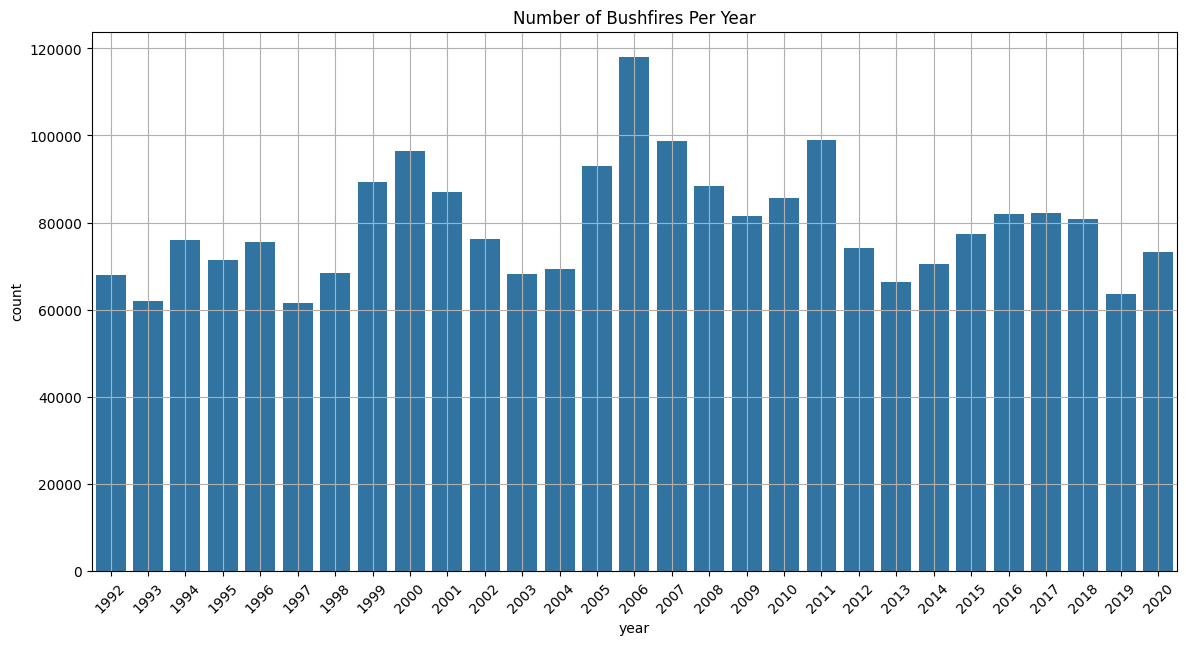

C:\Users\glori\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


KeyboardInterrupt: 

In [5]:
#Distribution of Fire Causes
# Plot the distribution of fire causes
plt.figure(figsize=(12, 6))
sns.countplot(data=bushfire_df, x='general_cause', order=bushfire_df['general_cause'].value_counts().index)
plt.title('Distribution of Bushfire Causes')
plt.xticks(rotation=45)
plt.show()

#Fire Size Distribution
# Plot fire size distribution
plt.figure(figsize=(14, 7))
sns.histplot(bushfire_df['fire_size'], bins=50, kde=True)
plt.title('Distribution of Fire Sizes')
plt.xlabel('Fire Size (Acres)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#Temporal Analysis of Fires
# Extract year from discovery_datetime
bushfire_df['year'] = bushfire_df['discovery_datetime'].dt.year

# Plot number of fires per year
plt.figure(figsize=(14, 7))
sns.countplot(data=bushfire_df, x='year', order=sorted(bushfire_df['year'].dropna().unique()))
plt.title('Number of Bushfires Per Year')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#Geographical Distribution Using Scatter Plot
# Scatter plot of fire locations
plt.figure(figsize=(10, 8))
sns.scatterplot(data=bushfire_df, x='longitude', y='latitude', hue='general_cause', alpha=0.6)
plt.title('Geographical Distribution of Bushfires')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()
